In [11]:

import sys
import pandas as pd
import numpy as np
import torch
import importlib
import json
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
from tqdm import tqdm
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, VPacker, HPacker, DrawingArea
from matplotlib.patches import Rectangle

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
)

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing")
DATA_DIR = PROJECT_DIR / "data"
CHKPT_DIR = PROJECT_DIR / "checkpoints"
CHKPT_COPY_DIR = PROJECT_DIR / "checkpoints copy"
RESULT_DIR = PROJECT_DIR / "testing_results"

sys.path.append(str(PROJECT_DIR))

import models.tf_to_tg as tf_to_tg_module
import models.tf_to_dna as tf_to_dna_module
import datasets.tftg_dataset as tftg_dataset_module
import scripts.build_tf_to_tg_train_data as tf_tg_data_builder
import plotting_utils
import utils
import warnings

warnings.filterwarnings(
    "ignore",
    message="You are using `torch.load` with `weights_only=False`.*",
    category=FutureWarning,
)

tf_tg_input_cache_dir = DATA_DIR / "tf_tg_training_cache"

all_evaluation_plot_dir = PROJECT_DIR / "plots" / "model_vs_test_set_evaluation_figs"
all_evaluation_plot_dir.mkdir(exist_ok=True)

In [22]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

In [ ]:
def find_latest_checkpoint(cell_type, sample_name, training_number=None) -> Path:
    sample_chkpt_dir = CHKPT_DIR / cell_type / sample_name
    
    if not sample_chkpt_dir.exists():
        logging.warning(f"No checkpoints found for {cell_type} {sample_name} in {sample_chkpt_dir}")
        return None
    
    if training_number is not None:
        slurm_job_dirs = [d for d in sample_chkpt_dir.iterdir() if d.is_dir() and d.name.startswith(f"tf_tg_train_{sample_name}_{training_number}")]
    else:
        slurm_job_dirs = [d for d in sample_chkpt_dir.iterdir() if d.is_dir() and d.name.startswith(f"tf_tg_train_{sample_name}_")]
    
    if not slurm_job_dirs:
        logging.warning(f"No checkpoint directories found for {cell_type} {sample_name} in {sample_chkpt_dir}")
        return None
    
    latest_chkpt_dir = max(slurm_job_dirs, key=lambda d: int(d.name.split("_")[-1]))
    slurm_job_id = latest_chkpt_dir.name.split("_")[-1]
    
    chkpt_files = list(latest_chkpt_dir.glob("epoch=*-val_auroc=*-val_loss=*.ckpt"))
    if not chkpt_files:
        logging.warning(f"No checkpoint files found for {sample_name} in {latest_chkpt_dir}")
        return None
    
    latest_chkpt_file = max(chkpt_files, key=lambda f: int(f.stem.split("-")[0].split("=")[1]))
    epoch = latest_chkpt_file.stem.split("-")[0].split("=")[1]
    
    logging.info(f"Latest checkpoint for {cell_type} {sample_name}: Job {slurm_job_id} Epoch {epoch}")
    return latest_chkpt_file

def load_tf_tg_regulation_model(
    tf_dna_model_path: Path, 
    tf_tg_model_path: Path,
    tf_embeddings_tensor: torch.Tensor,
    tf_mask_tensor: torch.Tensor
    ) -> tf_to_tg_module.TFTGRegulationModel:
    
    # 1) Recreate the base TF→DNA model with the same hyperparameters
    base_model = tf_to_dna_module.TFPeakBindingModel(
        tf_embedding_dim=128,
        hidden_dim=128,
        dropout=0.3,
        num_layers=4,
        num_heads=4,
        dim_head=32,
    )

    # 2) Wrap in Lightning module and load checkpoint
    lit_model = tf_to_dna_module.LitTFPeakBindingModel.load_from_checkpoint(
        checkpoint_path=tf_dna_model_path,
        model=base_model,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )

    # 4) Get the trained TF-DNA model and freeze it
    trained_tf_peak_model = lit_model.model
    trained_tf_peak_model.eval()
    for p in trained_tf_peak_model.parameters():
        p.requires_grad = False

    # 5) Create the TF-TG model object using the trained TF-DNA model, and load the trained model checkpoint
    tf_tg_model = tf_to_tg_module.LitTFTGRegulationModel.load_from_checkpoint(
        checkpoint_path=tf_tg_model_path,
        model=tf_to_tg_module.TFTGRegulationModel(
            pretrained_tf_peak_model=trained_tf_peak_model,
            d_model=128,
            tf_peak_chunk_size=256,
        ),
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )
    
    return tf_tg_model

def generate_model_predictions(model, data_loader, device, tf_idx_to_name, tg_idx_to_name):
    pooling_mode = "lse"
    pooling_temperature = 1.0

    model = model.to(device)
    model.eval()
    
    if device.type == "cuda":
        model = torch.compile(model, mode="reduce-overhead")

    tf_indices_list = []
    tg_indices_list = []
    all_scores = []

    with torch.inference_mode():
        for batch in tqdm(data_loader, desc="Evaluating", ncols=100):
            tf_indices = batch["tf_idx"].detach().cpu().numpy().ravel()
            tg_indices = batch["tg_idx"].detach().cpu().numpy().ravel()

            batch = tf_to_tg_module.move_batch_to_device(batch, device)

            with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=(device.type == "cuda")):
                edge_logits, _ = model(
                    tf_embedding=batch["tf_embedding"],
                    tf_mask=batch["tf_mask"],
                    peak_sequences=batch["peak_sequences"],
                    peak_accessibility=batch["peak_accessibility"],
                    peak_distance=batch["peak_distance"],
                    tf_expression=batch["tf_expression"],
                    tg_expression=batch["tg_expression"],
                    peak_mask=batch.get("peak_mask", None),
                    cell_mask=batch["cell_mask"],
                    pooling_mode=pooling_mode,
                    pooling_temperature=pooling_temperature,
                )

            scores = torch.sigmoid(edge_logits.float())

            tf_indices_list.append(tf_indices)
            tg_indices_list.append(tg_indices)
            all_scores.append(scores.detach().cpu().numpy().ravel())

    all_tf_indices_flat = np.concatenate(tf_indices_list)
    all_tg_indices_flat = np.concatenate(tg_indices_list)
    all_scores_flat = np.concatenate(all_scores)

    tf_names = [tf_idx_to_name[int(idx)].upper() for idx in all_tf_indices_flat]
    tg_names = [tg_idx_to_name[int(idx)].upper() for idx in all_tg_indices_flat]

    prediction_df = pd.DataFrame({
        "Source": tf_names,
        "Target": tg_names,
        "Score": all_scores_flat,
    })

    prediction_df = (
        prediction_df.groupby(["Source", "Target"], as_index=False)["Score"]
        .median()
    )

    return prediction_df

def create_ground_truth_comparison_df(score_df, ground_truth_lookup, ground_truth_name):
    gt_tfs, gt_tgs, gt_pairs_set = ground_truth_lookup

    src = score_df["Source"]
    tgt = score_df["Target"]
    
    # Subset the score_df to only include edges where both TF and TG are in the ground truth test set
    mask = src.isin(gt_tfs) & tgt.isin(gt_tgs)
    df = score_df.loc[mask].copy()
    
    # Build the ground truth labels for the subsetted DataFrame
    df["Source"] = src.loc[mask].values
    df["Target"] = tgt.loc[mask].values

    key = df["Source"] + "\t" + df["Target"]
    df["_in_gt"] = key.isin(gt_pairs_set).astype("int8")
    df["ground_truth_name"] = ground_truth_name

    return df

def create_tf_tg_index_to_name_mappings(metadata):
    tf_idx_to_name = {idx: name for name, idx in metadata["tf_name_to_idx"].items()}
    tg_idx_to_name = {idx: name for name, idx in metadata["tg_id_to_idx"].items()}
    return tf_idx_to_name, tg_idx_to_name

def create_tf_tg_label_df(tftg_inputs_test):
    # Create the TF-TG label DataFrame
    tftg_inputs_test.keys()
    test_tf_input = tftg_inputs_test["tf_name"]
    test_tg_input = tftg_inputs_test["tg_name"]
    test_labels = tftg_inputs_test["label"]

    # create TF-TG label DataFrame
    tf_tg_label_df = pd.DataFrame({
        "Source": test_tf_input,
        "Target": test_tg_input,
        "Label": test_labels,
    })

    tf_tg_label_df = tf_tg_label_df.drop_duplicates(["Source", "Target"])

    gt_df: pd.DataFrame = tf_tg_label_df[tf_tg_label_df["Label"] == 1] 
    gt_tfs = set(gt_df["Source"].str.upper().unique()) 
    gt_targets = set(gt_df["Target"].str.upper().unique()) 
    gt_pairs = set(gt_df["Source"].str.upper() + "\t" + gt_df["Target"].str.upper())
    
    return tf_tg_label_df, gt_pairs, gt_tfs, gt_targets

def load_and_standardize_method(name: str, info: dict) -> pd.DataFrame:
    """
    Load a GRN CSV and rename tf_col/target_col/score_col -> Source/Target/Score.
    Extra columns are preserved.
    """
    if info["path"].suffix == ".tsv":
        sep = "\t"
    elif info["path"].suffix == ".csv":
        sep = ","
    
    df = pd.read_csv(info["path"], sep=sep, header=0, index_col=None)

    tf_col     = info["tf_col"]
    target_col = info["target_col"]
    score_col  = info["score_col"]

    rename_map = {
        tf_col: "Source",
        target_col: "Target",
        score_col: "Score",
    }

    missing = [c for c in rename_map if c not in df.columns]
    if missing:
        raise ValueError(f"[{name}] Missing expected columns: {missing}. Got: {list(df.columns)}")

    df = df.rename(columns=rename_map)

    df = df[["Source", "Target", "Score"]]
    df["Source"] = df["Source"].astype(str).str.upper()
    df["Target"] = df["Target"].astype(str).str.upper()

    return df

def compute_metrics(name: str, df: pd.DataFrame, gt_pairs: set, score_threshold: float):    
    logging.info(f"    - After filtering to test set TFs, {len(df)} edges remain")
        
    labels = [1 if pair in gt_pairs else 0 for pair in df["Source"] + "\t" + df["Target"]]
    scores = df["Score"].tolist()
    
    labels = np.asarray(labels).astype(int).ravel()
    scores = np.asarray(scores).astype(float).ravel()

    preds = (scores >= score_threshold).astype(int)

    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)

    if len(np.unique(labels)) < 2:
        auroc = np.nan
        auprc = np.nan
        rand_auroc = np.nan
        rand_auprc = np.nan
    else:
        auroc = roc_auc_score(labels, scores)
        auprc = average_precision_score(labels, scores)

        rng = np.random.default_rng(42)
        rand_scores = rng.permutation(scores)

        rand_auroc = roc_auc_score(labels, rand_scores)
        rand_auprc = average_precision_score(labels, rand_scores)

    return pd.DataFrame([{
        "method_name": name,
        "auroc": auroc,
        "auprc": auprc,
        "rand_auroc": rand_auroc,
        "rand_auprc": rand_auprc,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "n_edges": len(labels),
        "n_pos": int(labels.sum()),
        "n_neg": int((labels == 0).sum()),
        "score_threshold": score_threshold,
    }])
    
def build_full_universe_from_gt(method_df, gt_edges, use_abs_scores=True, missing_score=0.0):
    universe_tfs = gt_edges["Source"].dropna().unique()
    universe_tgs = gt_edges["Target"].dropna().unique()

    gt_pairs = set(zip(gt_edges["Source"], gt_edges["Target"]))

    full_universe = (
        pd.MultiIndex
        .from_product([universe_tfs, universe_tgs], names=["Source", "Target"])
        .to_frame(index=False)
    )

    full_universe["_in_gt"] = [
        1 if pair in gt_pairs else 0
        for pair in zip(full_universe["Source"], full_universe["Target"])
    ]

    method_scores = method_df[["Source", "Target", "Score"]].copy()

    if use_abs_scores:
        method_scores["Score"] = method_scores["Score"].abs()

    # If method has duplicate Source-Target edges, keep strongest score
    method_scores = (
        method_scores
        .sort_values("Score", ascending=False)
        .drop_duplicates(["Source", "Target"], keep="first")
    )

    full_universe = full_universe.merge(
        method_scores,
        on=["Source", "Target"],
        how="left",
    )

    full_universe["Score"] = full_universe["Score"].fillna(missing_score)

    # print(f"Complete TF-target universe size: {len(full_universe):,}")
    # print(
    #     f"Positives in universe: {(full_universe['_in_gt'] == 1).sum():,}"
    #     f" | Negatives: {(full_universe['_in_gt'] == 0).sum():,}"
    # )

    return full_universe

In [4]:
mm10_tf_dna_path = CHKPT_DIR / "tf_dna_mm10_3671604" / "epoch=08-val_auroc=0.9177-val_loss=0.2783.ckpt"
hg38_tf_dna_path = CHKPT_DIR / "tf_dna_hg38_3683606" / "epoch=13-val_auroc=0.9566-val_loss=0.2042.ckpt"

tf_dna_model_checkpoints = {
    "mESC": mm10_tf_dna_path,
    "iPSC": hg38_tf_dna_path,
    "Macrophage": hg38_tf_dna_path,
    "K562": hg38_tf_dna_path
}

tf_tg_model_checkpoints = {
    "mESC": {
        "E7.5_rep1": CHKPT_DIR / "mESC" / "E7.5_rep1" / "tf_tg_train_E7.5_rep1_3675131" / "epoch_11_best_model.ckpt",
        "E7.5_rep2": find_latest_checkpoint("mESC", "E7.5_rep2"),
        "E8.5_rep1": find_latest_checkpoint("mESC", "E8.5_rep1", training_number="3691937"),
        "E8.5_rep2": find_latest_checkpoint("mESC", "E8.5_rep2"),
    },
    "iPSC": {
        "WT_D13_rep1": find_latest_checkpoint("iPSC", "WT_D13_rep1"),
    },
    "Macrophage": {
        "buffer_1": find_latest_checkpoint("Macrophage", "buffer_1", training_number="3685893"),
        "buffer_2": find_latest_checkpoint("Macrophage", "buffer_2"),
        "buffer_3": find_latest_checkpoint("Macrophage", "buffer_3"),
        "buffer_4": find_latest_checkpoint("Macrophage", "buffer_4"),
    },
    "K562": {
        "sample_1": find_latest_checkpoint("K562", "sample_1"),
    }
}

INFO - Latest checkpoint for mESC E7.5_rep2: Job 3696113 Epoch 54
INFO - Latest checkpoint for mESC E8.5_rep1: Job 3691937 Epoch 42
INFO - Latest checkpoint for mESC E8.5_rep2: Job 3696124 Epoch 46
INFO - Latest checkpoint for iPSC WT_D13_rep1: Job 3683642 Epoch 75
INFO - Latest checkpoint for Macrophage buffer_1: Job 3685893 Epoch 152
INFO - Latest checkpoint for Macrophage buffer_2: Job 3697587 Epoch 00
INFO - Latest checkpoint for Macrophage buffer_3: Job 3696133 Epoch 246
INFO - Latest checkpoint for Macrophage buffer_4: Job 3696147 Epoch 209
INFO - Latest checkpoint for K562 sample_1: Job 3692409 Epoch 63


In [ ]:
species = "mm10"
cell_type = "mESC"
sample_name = "E7.5_rep1"

project_data_dir = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data")

if species == "mm10":
    gene_ref_file = project_data_dir / "genome_data" / "genome_annotation" / "mm10" / "Mus_musculus.GRCm39.115.gtf.gz"
elif species == "hg38":
    gene_ref_file = project_data_dir / "genome_data" / "genome_annotation" / "hg38" / "Homo_sapiens.GRCh38.113.gtf.gz"

genome_fasta_path = project_data_dir / "genome_data" / "reference_genome" / f"{species}" / f"{species}.fa"
chrom_sizes_path = project_data_dir / "genome_data" / "reference_genome" / f"{species}" / f"{species}.chrom.sizes"
chrom_sizes_path = project_data_dir / "genome_data" / "reference_genome" / f"{species}" / f"{species}.chrom.sizes"

train_chroms = [str(i) for i in range(1, 16)]
val_chroms = [ str(i) for i in range(16, 18)]
test_chroms = [str(i) for i in range(18, 20)]

sample_input_data_dir = PROJECT_DIR / "data" / "sample_input_data" / cell_type / sample_name

# Load in the ATAC pseudobulk and filter to only include peaks on the test chromosomes
atac_pseudobulk = pd.read_parquet(sample_input_data_dir / "RE_pseudobulk.parquet")
dataset_peaks = atac_pseudobulk.index.to_list()
dataset_peaks = [peak for peak in dataset_peaks if peak.split(":", 1)[0].replace("chr", "") in test_chroms]
logging.info(f"Number of peaks in dataset on test chromosomes: {len(dataset_peaks)}")

# Create a peak to index map for the peaks on the test chromosomes
atac_peak_map = {peak: idx for idx, peak in enumerate(dataset_peaks)}

# Load in the RNA pseudobulk
rna_pseudobulk = pd.read_parquet(sample_input_data_dir / "TG_pseudobulk.parquet")
rna_pseudobulk_norm = rna_pseudobulk.copy()
rna_pseudobulk_norm.index = rna_pseudobulk_norm.index.str.upper()

# Load in the peak to gene distance
peak_to_gene_distance = pd.read_parquet(sample_input_data_dir / "peak_to_gene_dist.parquet")
peak_to_gene = peak_to_gene_distance.copy()
peak_to_gene["target_id_norm"] = peak_to_gene["target_id"].str.upper()

common_cells = sorted(set(rna_pseudobulk_norm.columns) & set(atac_pseudobulk.columns))

# Load the merged ground truth
cell_type_cache_dir = DATA_DIR / f"{cell_type}_cache"
merged_ground_truth_df = pd.read_parquet(cell_type_cache_dir / "merged_ground_truth.parquet")

# Split genes into train/val/test based on chromosome
train_genes, val_genes, test_genes = tf_tg_data_builder.split_genes_by_chromosome(
    gene_ref_file,
    train_chroms=train_chroms,
    val_chroms=val_chroms,
    test_chroms=test_chroms
    )

# Create the train/val/test splits of the ground truth based on the gene splits
gt_train_df, gt_val_df, gt_test_df = tf_tg_data_builder.create_train_val_test_splits(
    merged_ground_truth_df, train_genes, val_genes, test_genes
)
gt_test_df["Source"] = gt_test_df["Source"].astype(str).str.upper()
gt_test_df["Target"] = gt_test_df["Target"].astype(str).str.upper()

# Build TF, TG, and edge sets for quick lookup later
gt_test_df = gt_test_df[["Source", "Target"]].dropna()
gt_tfs = set(gt_test_df["Source"].unique())
gt_tgs = set(gt_test_df["Target"].unique())
gt_pairs = (gt_test_df["Source"] + "\t" + gt_test_df["Target"]).drop_duplicates()

# Construct the full universe of possible TF-TG pairs for the test set, 
# label them based on presence in the ground truth, and merge with method predictions
full_universe = (
    pd.MultiIndex
    .from_product([gt_tfs, gt_tgs], names=["Source", "Target"])
    .to_frame(index=False)
)

# Create a list of true and false interactions based on whether the candidate edge is in the ground truth
full_universe["_in_gt"] = (full_universe["Source"] + "\t" + full_universe["Target"]).isin(gt_pairs).astype("int8")

true_df = full_universe[full_universe["_in_gt"] == 1]
false_df = full_universe[full_universe["_in_gt"] == 0]

true_interactions = zip(true_df["Source"], true_df["Target"])
false_interactions = zip(false_df["Source"], false_df["Target"])

# Load the TF and TG name to index mappings from the training cache metadata
with open(cell_type_cache_dir / "tf_tg_training_cache" / sample_name / "metadata.json", "r") as f:
    metadata = json.load(f)
    
tf_name_to_idx = metadata["tf_name_to_idx"]
tg_id_to_idx = metadata["tg_id_to_idx"]

tf_idx_to_name, tg_idx_to_name = create_tf_tg_index_to_name_mappings(metadata)

# Use the TF and TG name to index mappings to convert the labeled DataFrame of all 
# possible TF-TG pairs into a labeled DataFrame with TF and TG indices
def convert_labeled_dataframe_to_indices(true_interactions, false_interactions, tf_name_to_idx, tg_id_to_idx):
    rows = []
    for tf, tg in true_interactions:
        rows.append((tf, tg, 1))
    for tf, tg in false_interactions:
        rows.append((tf, tg, 0))

    df = pd.DataFrame(rows, columns=["tf_name", "tg_id", "label"])
    df["tf_idx"] = df["tf_name"].str.upper().map(tf_name_to_idx)
    df["tg_idx"] = df["tg_id"].str.upper().map(tg_id_to_idx)

    missing_mask = df["tf_idx"].isna() | df["tg_idx"].isna()
    if missing_mask.any():
        n_missing = missing_mask.sum()
        logging.info(f"Dropping {n_missing} interactions with missing TF or TG indices.")
        df = df.loc[~missing_mask].copy()

    df["tf_idx"] = df["tf_idx"].astype(np.int64)
    df["tg_idx"] = df["tg_idx"].astype(np.int64)
    df["label"] = df["label"].astype(np.float32)

    return df

labeled_df = convert_labeled_dataframe_to_indices(
    true_interactions, 
    false_interactions, 
    tf_name_to_idx, 
    tg_id_to_idx
)

# Create the centered one-hot encoded ATAC peak array for the test set
logging.info("Creating centered one-hot encoded ATAC peak array for the test set...")
atac_peak_array = utils.create_centered_peak_onehot_array(
    peak_ids=dataset_peaks,
    genome_fasta=genome_fasta_path,
    chrom_sizes=utils.load_chrom_sizes(chrom_sizes_path),
    peak_id_to_idx=atac_peak_map,
    flank_size=128,
    dtype=np.uint8,
    pad_out_of_bounds=True,
    num_workers=10,
    show_progress=False,
    chunk_size=10000,
)
atac_peak_tensor = torch.as_tensor(atac_peak_array, dtype=torch.uint8).float()

logging.info(f"Constructing TF-TG lookup tables for test set evaluation")
tg_to_peak_info, cell_to_idx, atac_mat, rna_mat, gene_to_rna_idx = tf_tg_data_builder.prepare_tftg_lookup_tables(
    peak_to_gene=peak_to_gene,
    atac_peak_map=atac_peak_map,
    atac_pseudobulk=atac_pseudobulk,
    rna_pseudobulk_norm=rna_pseudobulk_norm,
    dataset_peaks=dataset_peaks,
    common_cells=common_cells,
    max_precompute_peaks=8,
)

# Build the compact TF-TG input dataset for the test set
common_build_kwargs = dict(
    max_peaks_per_tg=8,
    max_cells_per_pair=16,
    tg_to_peak_info=tg_to_peak_info,
    cell_to_idx=cell_to_idx,
    atac_mat=atac_mat,
    rna_mat=rna_mat,
    gene_to_rna_idx=gene_to_rna_idx,
    common_cells=common_cells,
    tf_name_to_idx=tf_name_to_idx,
    tg_id_to_idx=tg_id_to_idx,
)

logging.info("Building TF-TG input dataset for test set evaluation...")
tftg_inputs_test = tf_tg_data_builder.build_tftg_inputs(
    labeled_df,
    seed=125,
    silence=True,
    **common_build_kwargs,
)

# Load the lookup tensors
tf_embeddings_tensor = torch.load(
    cell_type_cache_dir / "tf_embeddings.pt",
    weights_only=True,
)
tf_mask_tensor = torch.load(
    cell_type_cache_dir / "tf_masks.pt",
    weights_only=True,
)

In [ ]:

# Create the dataset for the test set using the loaded inputs and lookup tensors
dataset = tftg_dataset_module.TFTGEdgeBagDataset(
    tftg_inputs_test,
    tf_embeddings_tensor=tf_embeddings_tensor,
    tf_mask_tensor=tf_mask_tensor,
    atac_peak_tensor=atac_peak_tensor
)

# Create the DataLoader for the test set
num_workers = 8
loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=(num_workers > 0),
    prefetch_factor=2 if num_workers > 0 else None,
    collate_fn=tftg_dataset_module.collate_tftg_edge_bags,
)

print(f"Created DataLoader with {len(dataset)} samples and batch size {loader.batch_size}")


Created DataLoader with 152761 samples and batch size 8


In [ ]:

tf_dna_model_chkpt = tf_dna_model_checkpoints[cell_type]
tf_tg_model_chkpt = tf_tg_model_checkpoints[cell_type][sample_name]

# Load the TF→TG model
tf_tg_model = load_tf_tg_regulation_model(
    tf_dna_model_chkpt, 
    tf_tg_model_chkpt, 
    tf_embeddings_tensor, 
    tf_mask_tensor
    )

# Generate the model predictions for the test set and create a DataFrame with TF names, TG names, and predicted scores
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
prediction_df = generate_model_predictions(tf_tg_model.model, loader, device, tf_idx_to_name, tg_idx_to_name)

In [26]:
cross_model_cell_type = "mESC"
cross_model_sample_name = "E8.5_rep1"
cross_model_chkpt = tf_tg_model_checkpoints[cross_model_cell_type][cross_model_sample_name]

cross_tf_tg_model = load_tf_tg_regulation_model(
    tf_dna_model_chkpt,
    cross_model_chkpt,
    tf_embeddings_tensor,
    tf_mask_tensor,
)

cross_model_prediction_df = generate_model_predictions(cross_tf_tg_model.model, loader, device, tf_idx_to_name, tg_idx_to_name)

Evaluating: 100%|█████████████████████████████████████████████| 19096/19096 [07:31<00:00, 42.32it/s]


In [27]:
label_by_method_dict = {}
score_by_method_dict = {}

OTHER_METHOD_MUON_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/other_method_grns")

other_method_grns = {}

linger_path       = OTHER_METHOD_MUON_DIR / "LINGER_muon" / f"linger_{cell_type}_{sample_name}.tsv"
scenic_plus_path  = OTHER_METHOD_MUON_DIR / "SCENIC_muon" / f"scenicplus_{cell_type}_{sample_name}.tsv"
cell_oracle_path  = OTHER_METHOD_MUON_DIR / "CellOracle_muon" / f"celloracle_{cell_type}_{sample_name}.tsv"
pando_path        = OTHER_METHOD_MUON_DIR / "Pando_muon" / f"pando_{cell_type}_{sample_name}.tsv"
figr_path         = OTHER_METHOD_MUON_DIR / "FigR_muon" / f"figr_{cell_type}_{sample_name}.tsv"

method_info = {
    "SCENIC+":    {"path": scenic_plus_path, "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
    "LINGER":     {"path": linger_path,      "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
    "CellOracle": {"path": cell_oracle_path, "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
    "Pando":      {"path": pando_path,       "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
    "FigR":       {"path": figr_path,        "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
}

standardized_method_dfs = {}
for method_name, info in method_info.items():
    df_std = load_and_standardize_method(method_name, info)
    
    mask = df_std["Source"].isin(gt_tfs) & df_std["Target"].isin(gt_tgs)
    df_filtered: pd.DataFrame = df_std.loc[mask]
    
    standardized_method_dfs[method_name] = df_filtered
    
# Add the TF-TG model predictions to the standardized_method_dfs for metric computation
standardized_method_dfs["MTGRN-STM"] = prediction_df
standardized_method_dfs["MTGRN-CTM"] = cross_model_prediction_df

label_by_method_dict[sample_name] = {}
score_by_method_dict[sample_name] = {}

# Compute metrics for each method and print results
for method_name, df in standardized_method_dfs.items():
    labels = [1 if pair in gt_pairs else 0 for pair in df["Source"] + "\t" + df["Target"]]
    scores = df["Score"].tolist()
    
    label_by_method_dict[sample_name][method_name] = labels
    score_by_method_dict[sample_name][method_name] = scores

TFs: 334
TGs: 1222
Edges: 93836


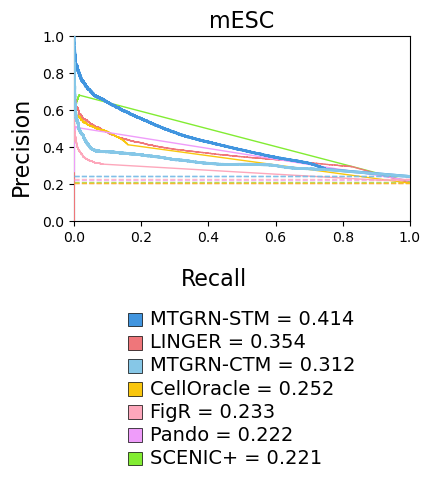

In [29]:
sample_to_title_map = {
    "E7.5_rep1": "mESC",
    # "buffer_1": "Macr-1",
    # "buffer_2": "Macr-2",
    # "WT_D13_rep1": "iPSC",
    # "sample_1": "K562"
}

method_color_dict = {
  "MTGRN-STM": "#4195df",
  "MTGRN-CTM": "#86C7E7",
  "LINGER": "#EF767A",
  "CellOracle": "#F9C60D",
  "Pando": "#EF9CFA",
  "SCENIC+": "#82EC32",
  "FigR": "#FDA7BB",
  "GRaNIE": "#F98637"
}

combined_fig, combined_axes = plt.subplots(
    nrows=1,
    ncols=len(sample_to_title_map),
    figsize=(4 * len(sample_to_title_map), 5),
    sharex=True,
    sharey=True,
    squeeze=False,
)

combined_axes = np.array(combined_axes, ndmin=1).ravel()

print(f"TFs: {len(gt_tfs)}")
print(f"TGs: {len(gt_tgs)}")
print(f"Edges: {len(gt_pairs)}")

gt_lookup = (gt_tfs, gt_tgs, set(gt_pairs))

for i, sample_name in enumerate(sample_to_title_map.keys()):
    
    ax = combined_axes[i]
    
    auprc_text_lines = []
    
    for method in label_by_method_dict[sample_name].keys():
        labels = label_by_method_dict[sample_name][method]
        scores = score_by_method_dict[sample_name][method]

        labels = np.asarray(labels).astype(int).ravel()
        scores = np.asarray(scores).astype(float).ravel()
        
        df_std = standardized_method_dfs[method]

        # Create the labeled DataFrame for the model predictions vs the test set ground truth
        method_labeled_df = create_ground_truth_comparison_df(df_std, gt_lookup, "test_chrom_gt")

        y = method_labeled_df["_in_gt"].fillna(0).astype(int).to_numpy()
        s = method_labeled_df["Score"].to_numpy()

        def sample_auprc_10x_negatives(full_universe, random_state=42):
            positives = full_universe[full_universe["_in_gt"] == 1]
            negatives = full_universe[full_universe["_in_gt"] == 0]

            n_pos = len(positives)
            n_neg_sample = min(n_pos * 10, len(negatives))

            if n_pos == 0 or n_neg_sample == 0:
                return full_universe.iloc[0:0].copy()

            neg_sampled = negatives.sample(
                n=n_neg_sample,
                replace=False,
                random_state=random_state,
            )

            auprc_df = pd.concat([positives, neg_sampled], axis=0)

            # Optional: shuffle, not required for sklearn metrics
            auprc_df = auprc_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

            return auprc_df

        full_universe_10x_negatives = sample_auprc_10x_negatives(full_universe, random_state=42)
                
        eval_df = full_universe_10x_negatives[["Source", "Target", "_in_gt"]].copy()

        auprc_df = eval_df.merge(
            method_labeled_df[["Source", "Target", "Score"]],
            on=["Source", "Target"],
            how="left",
        )
        
        auprc_df = auprc_df[auprc_df["Source"].isin(method_labeled_df["Source"].unique()) | ~auprc_df["Target"].isin(method_labeled_df["Target"].unique())].copy()

        auprc_df["Score"] = auprc_df["Score"].fillna(0)

        y_auprc = auprc_df["_in_gt"].astype(int).to_numpy()
        s_auprc = auprc_df["Score"].astype(float).to_numpy()

        auprc = average_precision_score(y_auprc, s_auprc)
        prec, rec, _ = precision_recall_curve(y_auprc, s_auprc)
        random_baseline = y_auprc.mean()

        method_color = method_color_dict.get(method, "#747474")
        auprc_text_lines.append((method, auprc, method_color))

        if method in ["MTGRN-STM", "MTGRN-CTM"]:
            line_weight = 2
        else:
            line_weight = 1

        ax.plot(
            rec,
            prec,
            lw=line_weight,
            color=method_color,
            label=f"",
            zorder=3,
        )
        
        
        ax.plot(
            [0, 1],
            [random_baseline, random_baseline],
            lw=1,
            linestyle="--",
            color=method_color,
            label="",
            zorder=3,
            alpha=0.75
        )
        
    auprc_text_lines_sorted = sorted(
        auprc_text_lines,
        key=lambda x: x[1],
        reverse=True,
    )

    ax.set_title(sample_to_title_map.get(sample_name, sample_name), fontsize=16)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Custom legend-like box below each plot
    legend_rows = []

    for method, auprc, method_color in auprc_text_lines_sorted:
        color_box = DrawingArea(12, 12, 0, 0)
        color_box.add_artist(
            Rectangle(
                (0, 1),
                10,
                10,
                facecolor=method_color,
                edgecolor="black",
                linewidth=0.5,
            )
        )

        label_text = TextArea(
            f"{method} = {auprc:.3f}",
            textprops=dict(
                color="black",
                fontsize=14,
            ),
        )

        row = HPacker(
            children=[color_box, label_text],
            align="center",
            pad=0,
            sep=4,
        )

        legend_rows.append(row)

    packed_legend = VPacker(
        children=legend_rows,
        align="left",
        pad=0,
        sep=3,
    )

    anchored_text = AnchoredOffsetbox(
        loc="upper center",
        child=packed_legend,
        pad=0.0,
        frameon=False,
        bbox_to_anchor=(0.5, -0.45),
        bbox_transform=ax.transAxes,
        borderpad=0.4,
    )

    ax.add_artist(anchored_text)

    # ax.tick_params(bottom=False, left=False)
    # ax.set_xticklabels([])
    # ax.set_yticklabels([])

combined_fig.text(
    0.5,
    0.32,
    "Recall",
    ha="center",
    fontsize=16,
)

combined_fig.text(
    -0.01,
    0.60,
    "Precision",
    va="center",
    rotation="vertical",
    fontsize=16,
)

combined_fig.subplots_adjust(
    left=0.15,
    right=0.99,
    bottom=0.45,
    top=0.82,
    wspace=0.08,
)

plt.show()

# combined_fig.savefig(
#     all_evaluation_plot_dir / "models_vs_own_test_set_prc.png",
#     dpi=300,
#     bbox_inches="tight",
# )

In [9]:
import sys
import pandas as pd
import numpy as np
import torch
import importlib
import json
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
from tqdm import tqdm
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, VPacker, HPacker, DrawingArea
from matplotlib.patches import Rectangle

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
)

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing")
DATA_DIR = PROJECT_DIR / "data"
CHKPT_DIR = PROJECT_DIR / "checkpoints"
CHKPT_COPY_DIR = PROJECT_DIR / "checkpoints copy"
RESULT_DIR = PROJECT_DIR / "testing_results"

sys.path.append(str(PROJECT_DIR))

import models.tf_to_tg as tf_to_tg_module
import models.tf_to_dna as tf_to_dna_module
import datasets.tftg_dataset as tftg_dataset_module
import scripts.build_tf_to_tg_train_data as tf_tg_data_builder
import utils
import warnings

warnings.filterwarnings(
    "ignore",
    message="You are using `torch.load` with `weights_only=False`.*",
    category=FutureWarning,
)

tf_tg_input_cache_dir = DATA_DIR / "tf_tg_training_cache"

all_evaluation_plot_dir = PROJECT_DIR / "plots" / "model_vs_test_set_evaluation_figs"
all_evaluation_plot_dir.mkdir(exist_ok=True)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

def find_latest_checkpoint(cell_type, sample_name, training_number=None) -> Path:
    sample_chkpt_dir = CHKPT_DIR / cell_type / sample_name
    
    if not sample_chkpt_dir.exists():
        logging.warning(f"No checkpoints found for {cell_type} {sample_name} in {sample_chkpt_dir}")
        return None
    
    if training_number is not None:
        slurm_job_dirs = [d for d in sample_chkpt_dir.iterdir() if d.is_dir() and d.name.startswith(f"tf_tg_train_{sample_name}_{training_number}")]
    else:
        slurm_job_dirs = [d for d in sample_chkpt_dir.iterdir() if d.is_dir() and d.name.startswith(f"tf_tg_train_{sample_name}_")]
    
    if not slurm_job_dirs:
        logging.warning(f"No checkpoint directories found for {cell_type} {sample_name} in {sample_chkpt_dir}")
        return None
    
    latest_chkpt_dir = max(slurm_job_dirs, key=lambda d: int(d.name.split("_")[-1]))
    slurm_job_id = latest_chkpt_dir.name.split("_")[-1]
    
    chkpt_files = list(latest_chkpt_dir.glob("epoch=*-val_auroc=*-val_loss=*.ckpt"))
    if not chkpt_files:
        logging.warning(f"No checkpoint files found for {sample_name} in {latest_chkpt_dir}")
        return None
    
    latest_chkpt_file = max(chkpt_files, key=lambda f: int(f.stem.split("-")[0].split("=")[1]))
    epoch = latest_chkpt_file.stem.split("-")[0].split("=")[1]
    
    logging.info(f"Latest checkpoint for {cell_type} {sample_name}: Job {slurm_job_id} Epoch {epoch}")
    return latest_chkpt_file

def load_tf_tg_regulation_model(
    tf_dna_model_path: Path, 
    tf_tg_model_path: Path,
    tf_embeddings_tensor: torch.Tensor,
    tf_mask_tensor: torch.Tensor
    ) -> tf_to_tg_module.TFTGRegulationModel:
    
    # 1) Recreate the base TF→DNA model with the same hyperparameters
    base_model = tf_to_dna_module.TFPeakBindingModel(
        tf_embedding_dim=128,
        hidden_dim=128,
        dropout=0.3,
        num_layers=4,
        num_heads=4,
        dim_head=32,
    )

    # 2) Wrap in Lightning module and load checkpoint
    lit_model = tf_to_dna_module.LitTFPeakBindingModel.load_from_checkpoint(
        checkpoint_path=tf_dna_model_path,
        model=base_model,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )

    # 4) Get the trained TF-DNA model and freeze it
    trained_tf_peak_model = lit_model.model
    trained_tf_peak_model.eval()
    for p in trained_tf_peak_model.parameters():
        p.requires_grad = False

    # 5) Create the TF-TG model object using the trained TF-DNA model, and load the trained model checkpoint
    tf_tg_model = tf_to_tg_module.LitTFTGRegulationModel.load_from_checkpoint(
        checkpoint_path=tf_tg_model_path,
        model=tf_to_tg_module.TFTGRegulationModel(
            pretrained_tf_peak_model=trained_tf_peak_model,
            d_model=128,
            tf_peak_chunk_size=256,
        ),
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )
    
    return tf_tg_model

def generate_model_predictions(model, data_loader, device, tf_idx_to_name, tg_idx_to_name):
    pooling_mode = "lse"
    pooling_temperature = 1.0

    model = model.to(device)
    model.eval()
    
    if device.type == "cuda":
        model = torch.compile(model, mode="reduce-overhead")

    tf_indices_list = []
    tg_indices_list = []
    all_scores = []

    with torch.inference_mode():
        for batch in tqdm(data_loader, desc="Evaluating", ncols=100):
            tf_indices = batch["tf_idx"].detach().cpu().numpy().ravel()
            tg_indices = batch["tg_idx"].detach().cpu().numpy().ravel()

            batch = tf_to_tg_module.move_batch_to_device(batch, device)

            with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=(device.type == "cuda")):
                edge_logits, _ = model(
                    tf_embedding=batch["tf_embedding"],
                    tf_mask=batch["tf_mask"],
                    peak_sequences=batch["peak_sequences"],
                    peak_accessibility=batch["peak_accessibility"],
                    peak_distance=batch["peak_distance"],
                    tf_expression=batch["tf_expression"],
                    tg_expression=batch["tg_expression"],
                    peak_mask=batch.get("peak_mask", None),
                    cell_mask=batch["cell_mask"],
                    pooling_mode=pooling_mode,
                    pooling_temperature=pooling_temperature,
                )

            scores = torch.sigmoid(edge_logits.float())

            tf_indices_list.append(tf_indices)
            tg_indices_list.append(tg_indices)
            all_scores.append(scores.detach().cpu().numpy().ravel())

    all_tf_indices_flat = np.concatenate(tf_indices_list)
    all_tg_indices_flat = np.concatenate(tg_indices_list)
    all_scores_flat = np.concatenate(all_scores)

    tf_names = [tf_idx_to_name[int(idx)].upper() for idx in all_tf_indices_flat]
    tg_names = [tg_idx_to_name[int(idx)].upper() for idx in all_tg_indices_flat]

    prediction_df = pd.DataFrame({
        "Source": tf_names,
        "Target": tg_names,
        "Score": all_scores_flat,
    })

    prediction_df = (
        prediction_df.groupby(["Source", "Target"], as_index=False)["Score"]
        .median()
    )

    return prediction_df

def create_ground_truth_comparison_df(score_df, ground_truth_lookup, ground_truth_name):
    gt_tfs, gt_tgs, gt_pairs_set = ground_truth_lookup

    src = score_df["Source"].str.upper()
    tgt = score_df["Target"].str.upper()
    
    # Subset the score_df to only include edges where both TF and TG are in the ground truth test set
    mask = src.isin(gt_tfs) & tgt.isin(gt_tgs)
    df = score_df.loc[mask].copy()
    
    # Build the ground truth labels for the subsetted DataFrame
    df["Source"] = src.loc[mask].values
    df["Target"] = tgt.loc[mask].values

    key = df["Source"] + "\t" + df["Target"]
    df["_in_gt"] = key.isin(gt_pairs_set).astype("int8")
    df["ground_truth_name"] = ground_truth_name

    return df

def create_tf_tg_index_to_name_mappings(metadata):
    tf_idx_to_name = {idx: name for name, idx in metadata["tf_name_to_idx"].items()}
    tg_idx_to_name = {idx: name for name, idx in metadata["tg_id_to_idx"].items()}
    return tf_idx_to_name, tg_idx_to_name

def create_tf_tg_label_df(tftg_inputs_test):
    # Create the TF-TG label DataFrame
    tftg_inputs_test.keys()
    test_tf_input = tftg_inputs_test["tf_name"]
    test_tg_input = tftg_inputs_test["tg_name"]
    test_labels = tftg_inputs_test["label"]

    # create TF-TG label DataFrame
    tf_tg_label_df = pd.DataFrame({
        "Source": test_tf_input,
        "Target": test_tg_input,
        "Label": test_labels,
    })

    tf_tg_label_df = tf_tg_label_df.drop_duplicates(["Source", "Target"])

    gt_df: pd.DataFrame = tf_tg_label_df[tf_tg_label_df["Label"] == 1] 
    gt_tfs = set(gt_df["Source"].str.upper().unique()) 
    gt_targets = set(gt_df["Target"].str.upper().unique()) 
    gt_pairs = set(gt_df["Source"].str.upper() + "\t" + gt_df["Target"].str.upper())
    
    return tf_tg_label_df, gt_pairs, gt_tfs, gt_targets

def load_and_standardize_method(name: str, info: dict) -> pd.DataFrame:
    """
    Load a GRN CSV and rename tf_col/target_col/score_col -> Source/Target/Score.
    Extra columns are preserved.
    """
    if info["path"].suffix == ".tsv":
        sep = "\t"
    elif info["path"].suffix == ".csv":
        sep = ","
    
    df = pd.read_csv(info["path"], sep=sep, header=0, index_col=None)

    tf_col     = info["tf_col"]
    target_col = info["target_col"]
    score_col  = info["score_col"]

    rename_map = {
        tf_col: "Source",
        target_col: "Target",
        score_col: "Score",
    }

    missing = [c for c in rename_map if c not in df.columns]
    if missing:
        raise ValueError(f"[{name}] Missing expected columns: {missing}. Got: {list(df.columns)}")

    df = df.rename(columns=rename_map)

    df = df[["Source", "Target", "Score"]]
    df["Source"] = df["Source"].astype(str).str.upper()
    df["Target"] = df["Target"].astype(str).str.upper()

    return df

def compute_metrics(name: str, df: pd.DataFrame, gt_pairs: set, score_threshold: float):            
    labels = [1 if pair in gt_pairs else 0 for pair in df["Source"] + "\t" + df["Target"]]
    scores = df["Score"].tolist()
    
    labels = np.asarray(labels).astype(int).ravel()
    scores = np.asarray(scores).astype(float).ravel()

    preds = (scores >= score_threshold).astype(int)

    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)

    if len(np.unique(labels)) < 2:
        auroc = np.nan
        auprc = np.nan
        rand_auroc = np.nan
        rand_auprc = np.nan
    else:
        auroc = roc_auc_score(labels, scores)
        auprc = average_precision_score(labels, scores)

        rng = np.random.default_rng(42)
        rand_scores = rng.permutation(scores)

        rand_auroc = roc_auc_score(labels, rand_scores)
        rand_auprc = average_precision_score(labels, rand_scores)

    return pd.DataFrame([{
        "method_name": name,
        "auroc": auroc,
        "auprc": auprc,
        "rand_auroc": rand_auroc,
        "rand_auprc": rand_auprc,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "n_edges": len(labels),
        "n_pos": int(labels.sum()),
        "n_neg": int((labels == 0).sum()),
        "score_threshold": score_threshold,
    }])
    
def build_full_universe_from_gt(method_df, gt_edges, use_abs_scores=True, missing_score=0.0):
    universe_tfs = gt_edges["Source"].dropna().unique()
    universe_tgs = gt_edges["Target"].dropna().unique()

    gt_pairs = set(zip(gt_edges["Source"], gt_edges["Target"]))

    full_universe = (
        pd.MultiIndex
        .from_product([universe_tfs, universe_tgs], names=["Source", "Target"])
        .to_frame(index=False)
    )

    full_universe["_in_gt"] = [
        1 if pair in gt_pairs else 0
        for pair in zip(full_universe["Source"], full_universe["Target"])
    ]

    method_scores = method_df[["Source", "Target", "Score"]].copy()

    if use_abs_scores:
        method_scores["Score"] = method_scores["Score"].abs()

    # If method has duplicate Source-Target edges, keep strongest score
    method_scores = (
        method_scores
        .sort_values("Score", ascending=False)
        .drop_duplicates(["Source", "Target"], keep="first")
    )

    full_universe = full_universe.merge(
        method_scores,
        on=["Source", "Target"],
        how="left",
    )

    full_universe["Score"] = full_universe["Score"].fillna(missing_score)

    # print(f"Complete TF-target universe size: {len(full_universe):,}")
    # print(
    #     f"Positives in universe: {(full_universe['_in_gt'] == 1).sum():,}"
    #     f" | Negatives: {(full_universe['_in_gt'] == 0).sum():,}"
    # )

    return full_universe

def convert_labeled_dataframe_to_indices(true_interactions, false_interactions, tf_name_to_idx, tg_id_to_idx):
    rows = []
    for tf, tg in true_interactions:
        rows.append((tf, tg, 1))
    for tf, tg in false_interactions:
        rows.append((tf, tg, 0))

    df = pd.DataFrame(rows, columns=["tf_name", "tg_id", "label"])
    df["tf_idx"] = df["tf_name"].str.upper().map(tf_name_to_idx)
    df["tg_idx"] = df["tg_id"].str.upper().map(tg_id_to_idx)

    missing_mask = df["tf_idx"].isna() | df["tg_idx"].isna()
    if missing_mask.any():
        n_missing = missing_mask.sum()
        logging.info(f"Dropping {n_missing} interactions with missing TF or TG indices.")
        df = df.loc[~missing_mask].copy()

    df["tf_idx"] = df["tf_idx"].astype(np.int64)
    df["tg_idx"] = df["tg_idx"].astype(np.int64)
    df["label"] = df["label"].astype(np.float32)

    return df

def sample_auprc_10x_negatives(full_universe, random_state=42):
    positives = full_universe[full_universe["_in_gt"] == 1]
    negatives = full_universe[full_universe["_in_gt"] == 0]

    n_pos = len(positives)
    n_neg_sample = min(n_pos * 10, len(negatives))

    if n_pos == 0 or n_neg_sample == 0:
        return full_universe.iloc[0:0].copy()

    neg_sampled = negatives.sample(
        n=n_neg_sample,
        replace=False,
        random_state=random_state,
    )

    auprc_df = pd.concat([positives, neg_sampled], axis=0)

    # Optional: shuffle, not required for sklearn metrics
    auprc_df = auprc_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    return auprc_df

mm10_tf_dna_path = CHKPT_DIR / "tf_dna_mm10_3671604" / "epoch=08-val_auroc=0.9177-val_loss=0.2783.ckpt"
hg38_tf_dna_path = CHKPT_DIR / "tf_dna_hg38_3683606" / "epoch=13-val_auroc=0.9566-val_loss=0.2042.ckpt"

tf_dna_model_checkpoints = {
    "mESC": mm10_tf_dna_path,
    "iPSC": hg38_tf_dna_path,
    "Macrophage": hg38_tf_dna_path,
    "K562": hg38_tf_dna_path
}

tf_tg_model_checkpoints = {
    "mESC": {
        "E7.5_rep1": CHKPT_DIR / "mESC" / "E7.5_rep1" / "tf_tg_train_E7.5_rep1_3675131" / "epoch_11_best_model.ckpt",
        "E7.5_rep2": find_latest_checkpoint("mESC", "E7.5_rep2"),
        "E8.5_rep1": find_latest_checkpoint("mESC", "E8.5_rep1", training_number="3691937"),
        "E8.5_rep2": find_latest_checkpoint("mESC", "E8.5_rep2"),
    },
    "iPSC": {
        "WT_D13_rep1": find_latest_checkpoint("iPSC", "WT_D13_rep1"),
    },
    "Macrophage": {
        "buffer_1": find_latest_checkpoint("Macrophage", "buffer_1", training_number="3685893"),
        "buffer_2": find_latest_checkpoint("Macrophage", "buffer_2"),
        "buffer_3": find_latest_checkpoint("Macrophage", "buffer_3"),
        "buffer_4": find_latest_checkpoint("Macrophage", "buffer_4"),
    },
    "K562": {
        "sample_1": find_latest_checkpoint("K562", "sample_1"),
    }
}

evaluations = [
    ("mm10", "mESC", "E7.5_rep1"),
    ("hg38", "Macrophage", "buffer_1"),
    ("hg38", "Macrophage", "buffer_2"),
    ("hg38", "K562", "sample_1"),
    # ("hg38", "iPSC", "WT_D13_rep1"),
]
force_reload = False

cross_model_cell_type = "mESC"
cross_model_sample_name = "E8.5_rep1"
cross_model_chkpt = tf_tg_model_checkpoints[cross_model_cell_type][cross_model_sample_name]

project_data_dir = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data")

auprc_all_method_dfs = {}
for species, cell_type, sample_name in evaluations:
    logging.info(f"Evaluating on {cell_type} {sample_name} ({species})")
    if species == "mm10":
        gene_ref_file = project_data_dir / "genome_data" / "genome_annotation" / "mm10" / "Mus_musculus.GRCm39.115.gtf.gz"
    elif species == "hg38":
        gene_ref_file = project_data_dir / "genome_data" / "genome_annotation" / "hg38" / "Homo_sapiens.GRCh38.113.gtf.gz"

    genome_fasta_path = project_data_dir / "genome_data" / "reference_genome" / f"{species}" / f"{species}.fa"
    chrom_sizes_path = project_data_dir / "genome_data" / "reference_genome" / f"{species}" / f"{species}.chrom.sizes"
    chrom_sizes_path = project_data_dir / "genome_data" / "reference_genome" / f"{species}" / f"{species}.chrom.sizes"

    if species == "mm10":
        train_chroms = [str(i) for i in range(1, 16)]
        val_chroms = [ str(i) for i in range(16, 18)]
        test_chroms = [str(i) for i in range(18, 20)]
    elif species == "hg38":
        train_chroms = [str(i) for i in range(1, 18)]
        val_chroms = [str(i) for i in range(18, 20)]
        test_chroms = [str(i) for i in range(20, 23)]

    sample_input_data_dir = PROJECT_DIR / "data" / "sample_input_data" / cell_type / sample_name

    # Load in the ATAC pseudobulk and filter to only include peaks on the test chromosomes
    atac_pseudobulk = pd.read_parquet(sample_input_data_dir / "RE_pseudobulk.parquet")
    dataset_peaks = atac_pseudobulk.index.to_list()
    dataset_peaks = [peak for peak in dataset_peaks if peak.split(":", 1)[0].replace("chr", "") in test_chroms]

    # Create a peak to index map for the peaks on the test chromosomes
    atac_peak_map = {peak: idx for idx, peak in enumerate(dataset_peaks)}

    # Load in the RNA pseudobulk
    rna_pseudobulk = pd.read_parquet(sample_input_data_dir / "TG_pseudobulk.parquet")
    rna_pseudobulk_norm = rna_pseudobulk.copy()
    rna_pseudobulk_norm.index = rna_pseudobulk_norm.index.str.upper()

    # Load in the peak to gene distance
    peak_to_gene_distance = pd.read_parquet(sample_input_data_dir / "peak_to_gene_dist.parquet")
    peak_to_gene = peak_to_gene_distance.copy()
    peak_to_gene["target_id_norm"] = peak_to_gene["target_id"].str.upper()

    common_cells = sorted(set(rna_pseudobulk_norm.columns) & set(atac_pseudobulk.columns))

    # Load the merged ground truth
    cell_type_cache_dir = DATA_DIR / f"{cell_type}_cache"
    merged_ground_truth_df = pd.read_parquet(cell_type_cache_dir / f"{cell_type}_merged_ground_truth.parquet")

    # Split genes into train/val/test based on chromosome
    train_genes, val_genes, test_genes = tf_tg_data_builder.split_genes_by_chromosome(
        gene_ref_file,
        train_chroms=train_chroms,
        val_chroms=val_chroms,
        test_chroms=test_chroms
        )

    # Create the train/val/test splits of the ground truth based on the gene splits
    gt_train_df, gt_val_df, gt_test_df = tf_tg_data_builder.create_train_val_test_splits(
        merged_ground_truth_df, train_genes, val_genes, test_genes
    )
    gt_test_df["Source"] = gt_test_df["Source"].astype(str).str.upper()
    gt_test_df["Target"] = gt_test_df["Target"].astype(str).str.upper()

    # Build TF, TG, and edge sets for quick lookup later
    gt_test_df = gt_test_df[["Source", "Target"]].dropna()
    gt_tfs = set(gt_test_df["Source"].unique())
    gt_tgs = set(gt_test_df["Target"].unique())
    gt_pairs = (gt_test_df["Source"] + "\t" + gt_test_df["Target"]).drop_duplicates()
    
    gt_lookup = (gt_tfs, gt_tgs, set(gt_pairs))
    
    
    sample_full_grn_dir = RESULT_DIR / "full_test_grns" / cell_type / sample_name
    sample_full_grn_dir.mkdir(parents=True, exist_ok=True)
    
    cross_tf_tg_df_file = sample_full_grn_dir / f"tf_tg_cross_model_predictions_{cross_model_cell_type}_{cross_model_sample_name}.tsv"
    sample_full_grn_file = sample_full_grn_dir / f"tf_tg_predictions_{cell_type}_{sample_name}.tsv"
    
    # Construct the full universe of possible TF-TG pairs for the test set, 
    # label them based on presence in the ground truth, and merge with method predictions
    full_universe = (
        pd.MultiIndex
        .from_product([gt_tfs, gt_tgs], names=["Source", "Target"])
        .to_frame(index=False)
    )

    # Create a list of true and false interactions based on whether the candidate edge is in the ground truth
    full_universe["_in_gt"] = (full_universe["Source"] + "\t" + full_universe["Target"]).isin(gt_pairs).astype("int8")

    true_df = full_universe[full_universe["_in_gt"] == 1]
    false_df = full_universe[full_universe["_in_gt"] == 0]
    
    if not sample_full_grn_file.exists() and not cross_tf_tg_df_file.exists() or force_reload == True:
        true_interactions = zip(true_df["Source"], true_df["Target"])
        false_interactions = zip(false_df["Source"], false_df["Target"])

        # Load the TF and TG name to index mappings from the training cache metadata
        with open(cell_type_cache_dir / "tf_tg_training_cache" / sample_name / "metadata.json", "r") as f:
            metadata = json.load(f)
            
        tf_name_to_idx = metadata["tf_name_to_idx"]
        tg_id_to_idx = metadata["tg_id_to_idx"]

        tf_idx_to_name, tg_idx_to_name = create_tf_tg_index_to_name_mappings(metadata)

        # Use the TF and TG name to index mappings to convert the labeled DataFrame of all 
        # possible TF-TG pairs into a labeled DataFrame with TF and TG indices
        labeled_df = convert_labeled_dataframe_to_indices(
            true_interactions, 
            false_interactions, 
            tf_name_to_idx, 
            tg_id_to_idx
        )

        # Create the centered one-hot encoded ATAC peak array for the test set
        atac_peak_array = utils.create_centered_peak_onehot_array(
            peak_ids=dataset_peaks,
            genome_fasta=genome_fasta_path,
            chrom_sizes=utils.load_chrom_sizes(chrom_sizes_path),
            peak_id_to_idx=atac_peak_map,
            flank_size=128,
            dtype=np.uint8,
            pad_out_of_bounds=True,
            num_workers=10,
            show_progress=False,
            chunk_size=10000,
        )
        atac_peak_tensor = torch.as_tensor(atac_peak_array, dtype=torch.uint8).float()

        # Prepare the lookup tables needed to build the TF-TG input dataset for the test set
        tg_to_peak_info, cell_to_idx, atac_mat, rna_mat, gene_to_rna_idx = tf_tg_data_builder.prepare_tftg_lookup_tables(
            peak_to_gene=peak_to_gene,
            atac_peak_map=atac_peak_map,
            atac_pseudobulk=atac_pseudobulk,
            rna_pseudobulk_norm=rna_pseudobulk_norm,
            dataset_peaks=dataset_peaks,
            common_cells=common_cells,
            max_precompute_peaks=8,
        )

        # Build the compact TF-TG input dataset for the test set
        common_build_kwargs = dict(
            max_peaks_per_tg=8,
            max_cells_per_pair=16,
            tg_to_peak_info=tg_to_peak_info,
            cell_to_idx=cell_to_idx,
            atac_mat=atac_mat,
            rna_mat=rna_mat,
            gene_to_rna_idx=gene_to_rna_idx,
            common_cells=common_cells,
            tf_name_to_idx=tf_name_to_idx,
            tg_id_to_idx=tg_id_to_idx,
        )

        tftg_inputs_test = tf_tg_data_builder.build_tftg_inputs(
            labeled_df,
            seed=125,
            silence=True,
            **common_build_kwargs,
        )

        # Load the lookup tensors
        tf_embeddings_tensor = torch.load(
            cell_type_cache_dir / "tf_embeddings.pt",
            weights_only=True,
        )
        tf_mask_tensor = torch.load(
            cell_type_cache_dir / "tf_masks.pt",
            weights_only=True,
        )
        
        # Create the dataset for the test set using the loaded inputs and lookup tensors
        dataset = tftg_dataset_module.TFTGEdgeBagDataset(
            tftg_inputs_test,
            tf_embeddings_tensor=tf_embeddings_tensor,
            tf_mask_tensor=tf_mask_tensor,
            atac_peak_tensor=atac_peak_tensor
        )

        # Create the DataLoader for the test set
        num_workers = 8
        loader = DataLoader(
            dataset,
            batch_size=512,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=True,
            persistent_workers=(num_workers > 0),
            prefetch_factor=2 if num_workers > 0 else None,
            collate_fn=tftg_dataset_module.collate_tftg_edge_bags,
        )

        tf_dna_model_chkpt = tf_dna_model_checkpoints[cell_type]
        tf_tg_model_chkpt = tf_tg_model_checkpoints[cell_type][sample_name]

        # Generate the model predictions for the test set and create a DataFrame with TF names, TG names, and predicted scores
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        # Load the TF→TG model
        tf_tg_model = load_tf_tg_regulation_model(
            tf_dna_model_chkpt, 
            tf_tg_model_chkpt, 
            tf_embeddings_tensor, 
            tf_mask_tensor
            )
        
        # Run the model on the test set and generate the predictions DataFrame
        prediction_df = generate_model_predictions(tf_tg_model.model, loader, device, tf_idx_to_name, tg_idx_to_name)
        
        prediction_df.to_csv(sample_full_grn_file, sep="\t", index=False)
        
        cross_tf_tg_model = load_tf_tg_regulation_model(
            tf_dna_model_chkpt,
            cross_model_chkpt,
            tf_embeddings_tensor,
            tf_mask_tensor,
        )
        
        cross_model_prediction_df = generate_model_predictions(cross_tf_tg_model.model, loader, device, tf_idx_to_name, tg_idx_to_name)

        cross_model_prediction_df.to_csv(cross_tf_tg_df_file, sep="\t", index=False)
        
    else:
        prediction_df = pd.read_csv(sample_full_grn_file, sep="\t", header=0)
        cross_model_prediction_df = pd.read_csv(cross_tf_tg_df_file, sep="\t", header=0)

    OTHER_METHOD_MUON_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/other_method_grns")

    other_method_grns = {}

    linger_path       = OTHER_METHOD_MUON_DIR / "LINGER_muon" / f"linger_{cell_type}_{sample_name}.tsv"
    scenic_plus_path  = OTHER_METHOD_MUON_DIR / "SCENIC_muon" / f"scenicplus_{cell_type}_{sample_name}.tsv"
    cell_oracle_path  = OTHER_METHOD_MUON_DIR / "CellOracle_muon" / f"celloracle_{cell_type}_{sample_name}.tsv"
    pando_path        = OTHER_METHOD_MUON_DIR / "Pando_muon" / f"pando_{cell_type}_{sample_name}.tsv"
    figr_path         = OTHER_METHOD_MUON_DIR / "FigR_muon" / f"figr_{cell_type}_{sample_name}.tsv"

    method_info = {
        "SCENIC+":    {"path": scenic_plus_path, "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
        "LINGER":     {"path": linger_path,      "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
        "CellOracle": {"path": cell_oracle_path, "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
        "Pando":      {"path": pando_path,       "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
        "FigR":       {"path": figr_path,        "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
    }

    standardized_method_dfs = {}
    for method_name, info in method_info.items():
        df_std = load_and_standardize_method(method_name, info)
        
        mask = df_std["Source"].isin(gt_tfs) & df_std["Target"].isin(gt_tgs)
        df_filtered: pd.DataFrame = df_std.loc[mask]
        
        standardized_method_dfs[method_name] = df_filtered
        
    # Add the TF-TG model predictions to the standardized_method_dfs for metric computation
    standardized_method_dfs["MTGRN-STM"] = prediction_df
    standardized_method_dfs["MTGRN-CTM"] = cross_model_prediction_df

    auprc_all_method_dfs[sample_name] = {}
    
    full_universe_10x_negatives = sample_auprc_10x_negatives(full_universe, random_state=42)
    
    # Compute metrics for each method and print results
    for method_name, df_std in standardized_method_dfs.items():
        
        # Create the labeled DataFrame for the model predictions vs the test set ground truth
        method_labeled_df = create_ground_truth_comparison_df(df_std, gt_lookup, "test_chrom_gt")

        y = method_labeled_df["_in_gt"].fillna(0).astype(int).to_numpy()
        s = method_labeled_df["Score"].to_numpy()
                
        eval_df = full_universe_10x_negatives[["Source", "Target", "_in_gt"]].copy()

        auprc_df = eval_df.merge(
            method_labeled_df[["Source", "Target", "Score"]],
            on=["Source", "Target"],
            how="left",
        )

        auprc_df["Score"] = auprc_df["Score"].fillna(0)
        
        auprc_all_method_dfs[sample_name][method_name] = auprc_df

import pickle
pickle.dump(auprc_all_method_dfs, open(RESULT_DIR / "auprc_all_method_dfs.pkl", "wb"))

INFO - Latest checkpoint for mESC E7.5_rep2: Job 3696113 Epoch 76
INFO - Latest checkpoint for mESC E8.5_rep1: Job 3691937 Epoch 42
INFO - Latest checkpoint for mESC E8.5_rep2: Job 3696124 Epoch 67
INFO - Latest checkpoint for iPSC WT_D13_rep1: Job 3683642 Epoch 75
INFO - Latest checkpoint for Macrophage buffer_1: Job 3685893 Epoch 152
INFO - Latest checkpoint for Macrophage buffer_2: Job 3685903 Epoch 53
INFO - Latest checkpoint for Macrophage buffer_3: Job 3696133 Epoch 249
INFO - Latest checkpoint for Macrophage buffer_4: Job 3696147 Epoch 209
INFO - Latest checkpoint for K562 sample_1: Job 3692409 Epoch 63
INFO - Evaluating on mESC E7.5_rep1 (mm10)


INFO - Splitting genes into train/val/test based on chromosome:
INFO - Extracted GTF attributes: ['gene_id', 'gene_version', 'gene_name', 'gene_source', 'gene_biotype', 'transcript_id', 'transcript_version', 'transcript_name', 'transcript_source', 'transcript_biotype', 'tag', 'transcript_support_level', 'exon_number', 'exon_id', 'exon_version', 'protein_id', 'protein_version', 'ccds_id']
INFO -   - Train set: 62,426 genes (chroms 1-9)
INFO -   - Validation set: 5,700 genes (chroms 16-17)
INFO -   - Test set: 4,099 genes (chroms 18-19)
INFO - Train interactions: 6590425
INFO - Validation interactions: 580265
INFO - Test interactions: 480491
INFO - Evaluating on Macrophage buffer_1 (hg38)
INFO - Splitting genes into train/val/test based on chromosome:
INFO - Extracted GTF attributes: ['gene_id', 'gene_version', 'gene_name', 'gene_source', 'gene_biotype', 'transcript_id', 'transcript_version', 'transcript_name', 'transcript_source', 'transcript_biotype', 'tag', 'transcript_support_level',

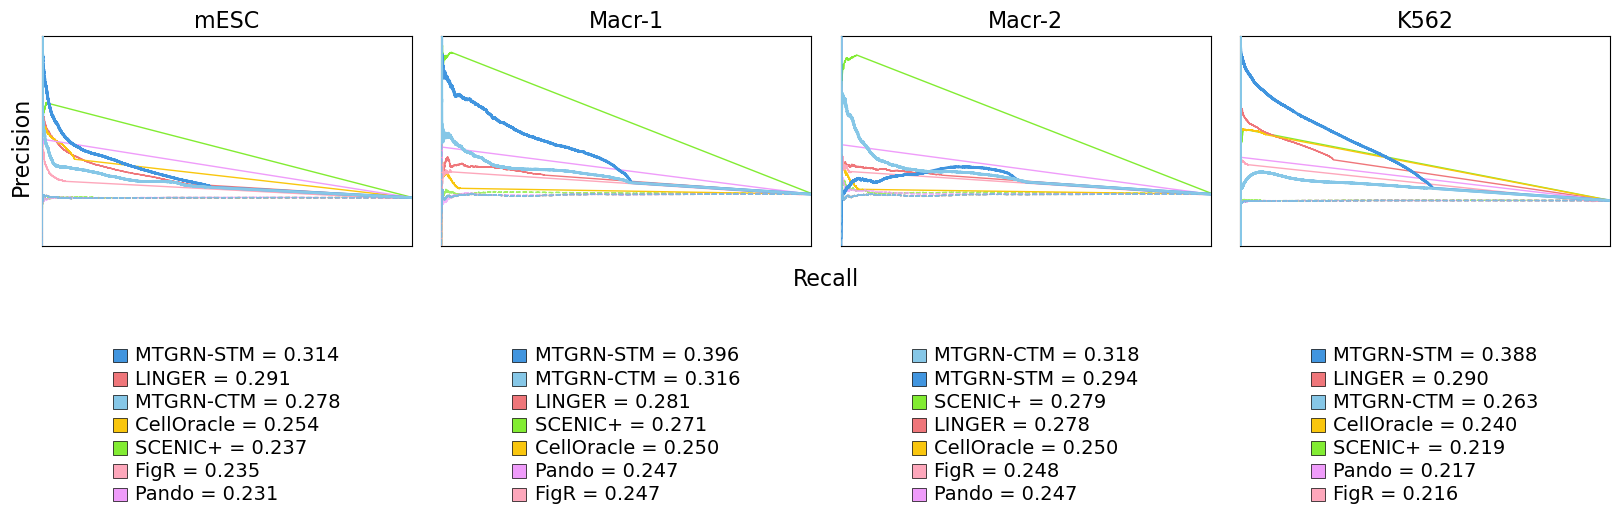

In [10]:
import plotting_utils

sample_to_title_map = {
    "E7.5_rep1": "mESC",
    "buffer_1": "Macr-1",
    "buffer_2": "Macr-2",
    # "WT_D13_rep1": "iPSC",
    "sample_1": "K562"
}

method_color_dict = {
  "MTGRN-STM": "#4195df",
  "MTGRN-CTM": "#86C7E7",
  "LINGER": "#EF767A",
  "CellOracle": "#F9C60D",
  "Pando": "#EF9CFA",
  "SCENIC+": "#82EC32",
  "FigR": "#FDA7BB",
  "GRaNIE": "#F98637"
}

combined_fig, combined_axes = plt.subplots(
    nrows=1,
    ncols=len(sample_to_title_map),
    figsize=(16, 5),
    sharex=True,
    sharey=True,
    squeeze=False,
)

combined_axes = np.array(combined_axes, ndmin=1).ravel()

cell_type_method_auroc = {}
for i, sample_name in enumerate(sample_to_title_map.keys()):
    
    ax = combined_axes[i]
    
    auprc_text_lines = []
    
    cell_type_method_auroc[sample_name] = {}
    
    for method in auprc_all_method_dfs[sample_name].keys():
        
        auprc_df = auprc_all_method_dfs[sample_name][method]

        y_auprc = auprc_df["_in_gt"].astype(int).to_numpy()
        s_auprc = auprc_df["Score"].astype(float).to_numpy()

        auprc = average_precision_score(y_auprc, s_auprc)
        prec, rec, _ = precision_recall_curve(y_auprc, s_auprc)
        
        cell_type_method_auroc[sample_name][method] = auprc
        
        rand_scores = plotting_utils._create_random_distribution(s_auprc)
        rand_prec, rand_rec, _ = precision_recall_curve(y_auprc, rand_scores)
        rand_auprc = average_precision_score(y_auprc, rand_scores)

        method_color = method_color_dict.get(method, "#747474")
        auprc_text_lines.append((method, auprc, method_color))

        if method in ["MTGRN-STM", "MTGRN-CTM"]:
            line_weight = 2
        else:
            line_weight = 1

        ax.plot(
            rec,
            prec,
            lw=line_weight,
            color=method_color,
            label=f"",
            zorder=3,
        )
        
        
        ax.plot(
            rand_rec,
            rand_prec,
            lw=1,
            linestyle="--",
            color=method_color,
            label="",
            zorder=3,
            alpha=0.75
        )
        
    auprc_text_lines_sorted = sorted(
        auprc_text_lines,
        key=lambda x: x[1],
        reverse=True,
    )

    ax.set_title(sample_to_title_map.get(sample_name, sample_name), fontsize=16)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Custom legend-like box below each plot
    legend_rows = []

    for method, auprc, method_color in auprc_text_lines_sorted:
        color_box = DrawingArea(12, 12, 0, 0)
        color_box.add_artist(
            Rectangle(
                (0, 1),
                10,
                10,
                facecolor=method_color,
                edgecolor="black",
                linewidth=0.5,
            )
        )

        label_text = TextArea(
            f"{method} = {auprc:.3f}",
            textprops=dict(
                color="black",
                fontsize=14,
            ),
        )

        row = HPacker(
            children=[color_box, label_text],
            align="center",
            pad=0,
            sep=4,
        )

        legend_rows.append(row)

    packed_legend = VPacker(
        children=legend_rows,
        align="left",
        pad=0,
        sep=3,
    )

    anchored_text = AnchoredOffsetbox(
        loc="upper center",
        child=packed_legend,
        pad=0.0,
        frameon=False,
        bbox_to_anchor=(0.5, -0.45),
        bbox_transform=ax.transAxes,
        borderpad=0.4,
    )

    ax.add_artist(anchored_text)

    ax.tick_params(bottom=False, left=False)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

combined_fig.text(
    0.5,
    0.32,
    "Recall",
    ha="center",
    fontsize=16,
)

combined_fig.text(
    -0.01,
    0.60,
    "Precision",
    va="center",
    rotation="vertical",
    fontsize=16,
)

combined_fig.subplots_adjust(
    left=0.01,
    right=0.99,
    bottom=0.40,
    top=0.82,
    wspace=0.08,
)

plt.show()

combined_fig.savefig(
    all_evaluation_plot_dir / "models_vs_own_test_set_prc.png",
    dpi=300,
    bbox_inches="tight",
)

In [11]:
cell_type_method_auroc

{'E7.5_rep1': {'SCENIC+': 0.2366892338185687,
  'LINGER': 0.29084397547693225,
  'CellOracle': 0.25355012404738875,
  'Pando': 0.231028241450968,
  'FigR': 0.23500558611218142,
  'MTGRN-STM': 0.31413780373238137,
  'MTGRN-CTM': 0.27782916349657916},
 'buffer_1': {'SCENIC+': 0.2706910332137577,
  'LINGER': 0.28055110154554674,
  'CellOracle': 0.2501986331836023,
  'Pando': 0.24704358620265132,
  'FigR': 0.2470206919021621,
  'MTGRN-STM': 0.39568688311240646,
  'MTGRN-CTM': 0.3155393692813818},
 'buffer_2': {'SCENIC+': 0.27900632726328567,
  'LINGER': 0.2778473082000682,
  'CellOracle': 0.25035278465251765,
  'Pando': 0.24694801074402484,
  'FigR': 0.24809057966007747,
  'MTGRN-STM': 0.29365279417805007,
  'MTGRN-CTM': 0.31834319160826746},
 'sample_1': {'SCENIC+': 0.2194068765375028,
  'LINGER': 0.2901241391500927,
  'CellOracle': 0.2395307454713145,
  'Pando': 0.21678795687951175,
  'FigR': 0.21618070290020908,
  'MTGRN-STM': 0.3877796973632973,
  'MTGRN-CTM': 0.2629034593664526}}

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def auroc_dict_to_long_df(cell_type_method_auroc):
    """
    Converts:
        {
            sample: {
                method: auroc,
                ...
            },
            ...
        }

    into a long dataframe with columns:
        experiment, method, auroc
    """
    rows = []

    for experiment, method_scores in cell_type_method_auroc.items():
        for method, auroc in method_scores.items():
            rows.append({
                "experiment": experiment,
                "method": method,
                "auroc": auroc,
            })

    return pd.DataFrame(rows)


def rank_methods_by_experiment(df):
    """
    Calculates method rank within each experiment/cell type.
    Higher AUROC = better rank.
    """
    all_ranks_df = df.copy()

    all_ranks_df["rank"] = (
        all_ranks_df
        .groupby("experiment")["auroc"]
        .rank(method="min", ascending=False)
        .astype(int)
    )

    return all_ranks_df.sort_values(["experiment", "rank"])


def avg_rank_by_method(all_ranks_df):
    """
    Calculates average rank for each method across experiments.
    Lower average rank = better.
    """
    rank_df = (
        all_ranks_df
        .groupby("method", as_index=False)
        .agg(avg_rank=("rank", "mean"))
        .sort_values("avg_rank", ascending=True)
        .reset_index(drop=True)
    )

    return rank_df


def avg_rank_by_method_plot(avg_rank_df, method_color_dict, title, rename_map=None):
    fig = plt.figure(figsize=(6, 4))

    if rename_map is None:
        rename_map = {}

    order = avg_rank_df["method"].tolist()

    sns.barplot(
        data=avg_rank_df,
        x="method",
        y="avg_rank",
        order=order,
        hue="method",
        palette=method_color_dict,
        dodge=False,
        legend=False,
    )

    ax = plt.gca()

    new_labels = []
    for tick in ax.get_xticklabels():
        original = tick.get_text()
        new = rename_map.get(original, original)
        new_labels.append(new)

        if new in {"MTGRN", "MTGRN-STM", "MTGRN-CTM"}:
            tick.set_color(method_color_dict.get(original, "black"))
            tick.set_fontweight("bold")
        else:
            tick.set_color("black")
            tick.set_fontweight("normal")

    ax.set_xticklabels(new_labels, rotation=45, ha="right")

    ax.set_ylabel("Average Rank")
    ax.set_xlabel("")
    ax.set_title(title, fontsize=16)

    plt.tight_layout()
    return fig


def experiment_by_method_rank_heatmap(
    all_ranks_df,
    rank_df,
    method_color_dict,
    title=None,
    experiment_order=None,
    rename_map=None,
):
    if rename_map is None:
        rename_map = {}

    rank_heatmap_df = all_ranks_df.pivot(
        index="experiment",
        columns="method",
        values="rank",
    )

    method_order = rank_df["method"].tolist()

    if experiment_order is None:
        experiment_order = rank_heatmap_df.index.tolist()

    rank_heatmap_df = rank_heatmap_df.reindex(
        index=experiment_order,
        columns=method_order,
    )

    fig, ax = plt.subplots(figsize=(5, 4))

    sns.heatmap(
        rank_heatmap_df,
        annot=True,
        fmt=".0f",
        cmap="viridis_r",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Rank"},
        annot_kws={"size": 12, "fontweight": "bold"},
        ax=ax,
    )

    new_labels = []
    for tick in ax.get_xticklabels():
        original = tick.get_text()
        new = rename_map.get(original, original)
        new_labels.append(new)

        if new in {"MTGRN", "MTGRN-STM", "MTGRN-CTM"}:
            tick.set_color(method_color_dict.get(original, "black"))
            tick.set_fontweight("bold")
        else:
            tick.set_color("black")
            tick.set_fontweight("normal")
            
    # Rename y-axis experiment/sample labels
    new_y_labels = []
    for tick in ax.get_yticklabels():
        original = tick.get_text()
        new = rename_map.get(original, original)
        new_y_labels.append(new)

    ax.set_yticklabels(new_y_labels, rotation=0, fontsize=12)
    ax.set_xticklabels(new_labels, rotation=45, ha="right", fontsize=12)

    if title is None:
        ax.set_title("Method AUPRC Rank by Cell Type", fontsize=16)
    else:
        ax.set_title(title, fontsize=16)    
    
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.tight_layout()
    return fig

/tmp/ipykernel_2138229/1197001844.py:100: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right")


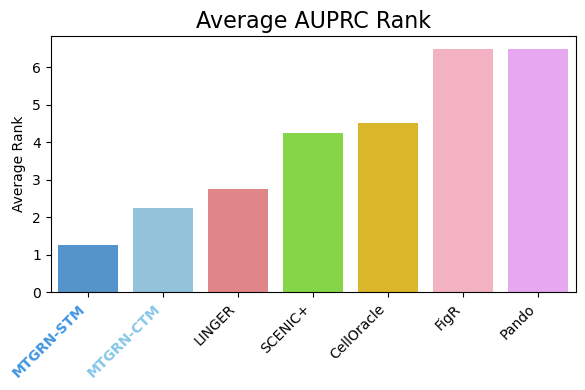

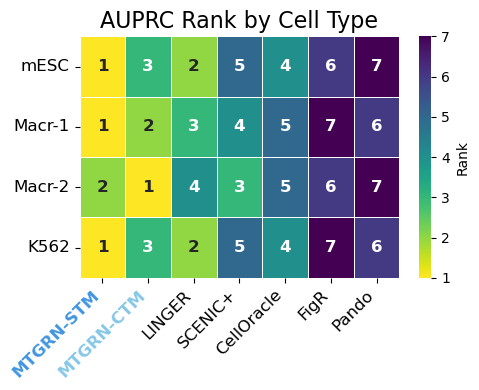

In [35]:
method_color_dict = {
    "MTGRN-STM": "#4195df",
    "MTGRN-CTM": "#86C7E7",
    "LINGER": "#EF767A",
    "CellOracle": "#F9C60D",
    "Pando": "#EF9CFA",
    "SCENIC+": "#82EC32",
    "FigR": "#FDA7BB",
}

experiment_order = [
    "E7.5_rep1",
    "buffer_1",
    "buffer_2",
    "sample_1",
]

rename_map = {
    "E7.5_rep1": "mESC",
    "buffer_1": "Macr-1",
    "buffer_2": "Macr-2",
    "sample_1": "K562",
}

auroc_df = auroc_dict_to_long_df(cell_type_method_auroc)

all_ranks_df = rank_methods_by_experiment(auroc_df)
rank_df = avg_rank_by_method(all_ranks_df)

avg_auprc_rank_fig = avg_rank_by_method_plot(
    rank_df,
    method_color_dict=method_color_dict,
    title="Average AUPRC Rank",
)

auprc_heatmap_fig = experiment_by_method_rank_heatmap(
    all_ranks_df,
    rank_df,
    method_color_dict=method_color_dict,
    experiment_order=experiment_order,
    rename_map=rename_map,
    title="AUPRC Rank by Cell Type",
)

avg_auprc_rank_fig.savefig(
    all_evaluation_plot_dir / "average_auprc_rank.png",
    dpi=300,
    bbox_inches="tight",
)

auprc_heatmap_fig.savefig(
    all_evaluation_plot_dir / "auprc_rank_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)